In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'uk-optimal-product-price-prediction' dataset.
Path to dataset files: /kaggle/input/uk-optimal-product-price-prediction


In [2]:
import pandas as pd
import os

amazon_uk = pd.read_csv(path + "/amz_uk_price_prediction_dataset.csv")
amazon_uk.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


Part 1: Understanding Product Categories
Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

Frequency Tables:

Generate a frequency table for the product category.
Which are the top 5 most listed product categories?
Visualizations:

Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?


In [3]:
category_counts = amazon_uk["category"].value_counts()
print(category_counts.head(10))


category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64


In [4]:
amazon_uk.sample(3000).to_csv("sample.csv", index=False)

In [5]:
print(amazon_uk.shape)
print(amazon_uk.dtypes)
print(amazon_uk.head(10).to_string())

(2443651, 9)
uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object
   uid        asin                                                                                                                                                                                               title  stars  reviews  price  isBestSeller  boughtInLastMonth        category
0    1  B09B96TG33                                                                                 Echo Dot (5th generation, 2022 release) | Big vibrant sound Wi-Fi and Bluetooth smart speaker with Alexa | Charcoal    4.7    15308  21.99         False                  0  Hi-Fi Speakers
1    2  B01HTH3C8S  Anker Soundcore mini, Super-Portable Bluetooth Speaker with 15-Hour Playtime, 66-Foot Bluetooth Range, Wireless Speake

#1.1.

In [6]:
freq_table = pd.DataFrame({
    'frequency': category_counts,
    'percentage': (category_counts / len(amazon_uk) * 100).round(2)
})

print(freq_table.head(10))

print()
print("Top 5")
top5 = freq_table.head(5)
print(top5)

                                        frequency  percentage
category                                                     
Sports & Outdoors                          836265       34.22
Beauty                                      19312        0.79
Handmade Clothing, Shoes & Accessories      19229        0.79
Bath & Body                                 19092        0.78
Birthday Gifts                              18978        0.78
Manicure & Pedicure Products                18940        0.78
Skin Care                                   18769        0.77
Make-up                                     18756        0.77
Hair Care                                   18735        0.77
Fragrances                                  18564        0.76

Top 5
                                        frequency  percentage
category                                                     
Sports & Outdoors                          836265       34.22
Beauty                                      19312        0.79
H

#1.2.

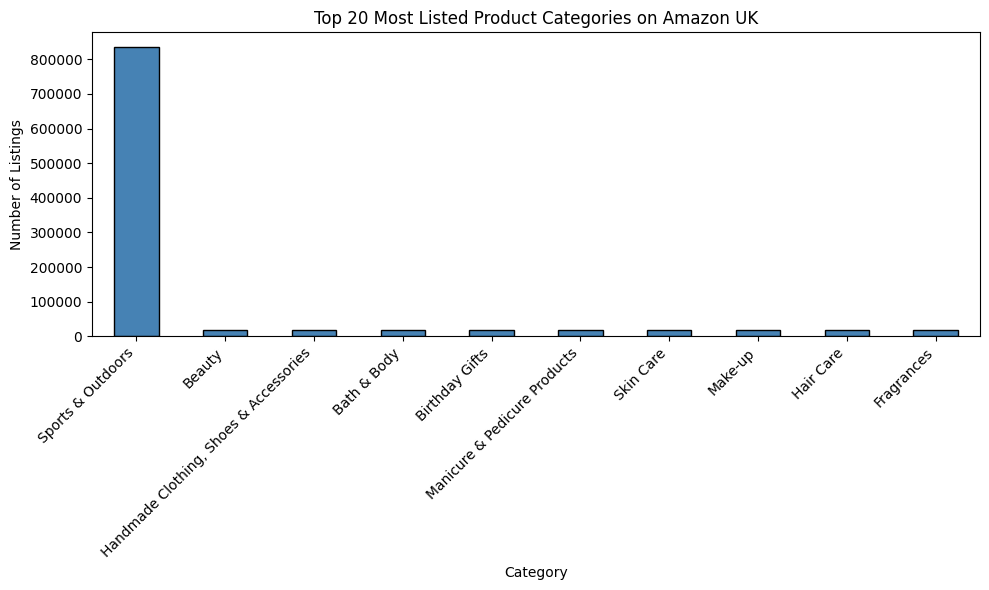

In [7]:
import matplotlib.pyplot as plt

top20 = category_counts.head(10)

plt.figure(figsize=(10, 6))
top20.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Most Listed Product Categories on Amazon UK')
plt.xlabel('Category')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


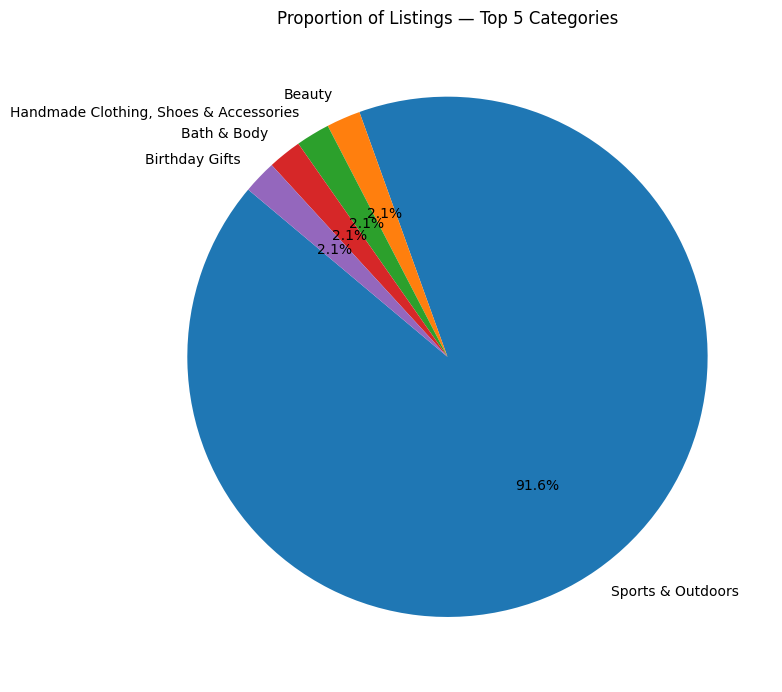

In [8]:
top10 = category_counts.head(5)

plt.figure(figsize=(8, 8))
plt.pie(
    top10,
    labels=top10.index,
    autopct='%1.1f%%',      # shows percentage on each slice
    startangle=140,          # rotates chart for better label spacing
    colors=plt.cm.tab10.colors
)
plt.title('Proportion of Listings — Top 5 Categories')
plt.tight_layout()
plt.show()

Yes, Sports and Outdoors dominate!

#2.1.

In [9]:
mean_price = amazon_uk["price"].mean()
median_price = amazon_uk["price"].median()
mode_price = amazon_uk["price"].mode()[0]

print(f"Mean price:   £{mean_price:.2f}")
print(f"Median price: £{median_price:.2f}")
print(f"Mode price:   £{mode_price:.2f}")

Mean price:   £89.24
Median price: £19.09
Mode price:   £9.99


In [10]:
mean_price = amazon_uk['price'].mean()
median_price = amazon_uk['price'].median()

difference = mean_price - median_price
percentage_diff = (difference / median_price) * 100

print(f"Mean price:        £{mean_price:.2f}")
print(f"Median price:      £{median_price:.2f}")
print(f"Difference:        £{difference:.2f}")
print(f"Mean is {percentage_diff:.1f}% higher than the median.")

Mean price:        £89.24
Median price:      £19.09
Difference:        £70.15
Mean is 367.5% higher than the median.


#2.2.

In [11]:
variance   = amazon_uk['price'].var()
std_dev    = amazon_uk['price'].std()
range      = amazon_uk['price'].max() - amazon_uk['price'].min()
q1         = amazon_uk['price'].quantile(0.25)
q3         = amazon_uk['price'].quantile(0.75)
iqr        = q3 - q1

print(f"Variance:           £²{variance:.2f}")
print(f"Standard Deviation: £{std_dev:.2f}")
print(f"Range:              £{range:.2f}")
print(f"Q1 (25th pct):      £{q1:.2f}")
print(f"Q3 (75th pct):      £{q3:.2f}")
print(f"IQR:                £{iqr:.2f}")

Variance:           £²119445.49
Standard Deviation: £345.61
Range:              £100000.00
Q1 (25th pct):      £9.99
Q3 (75th pct):      £45.99
IQR:                £36.00


#2.3.

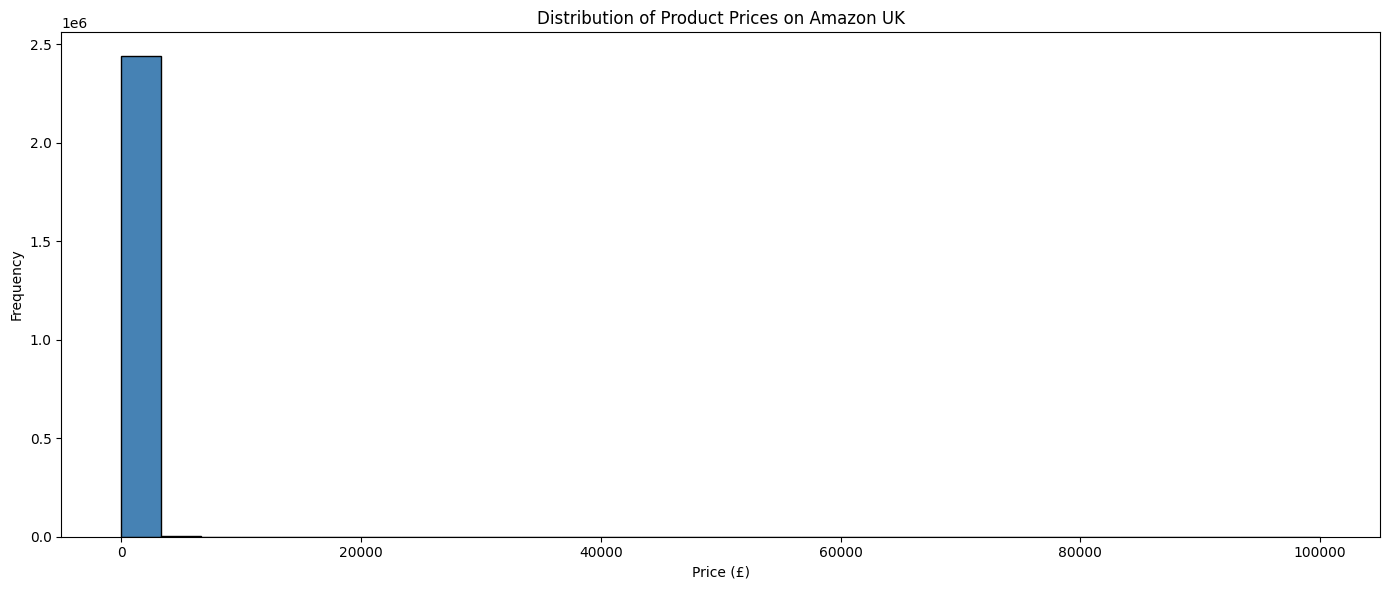

In [12]:
plt.figure(figsize=(14, 6))
amazon_uk['price'].plot(kind='hist', bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Product Prices on Amazon UK')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This is because a few very expensive products stretch the x-axis massively, squashing everything else into one corner. The solution is to cap the x-axis at a reasonable price limit, focusing on where most products actually are.

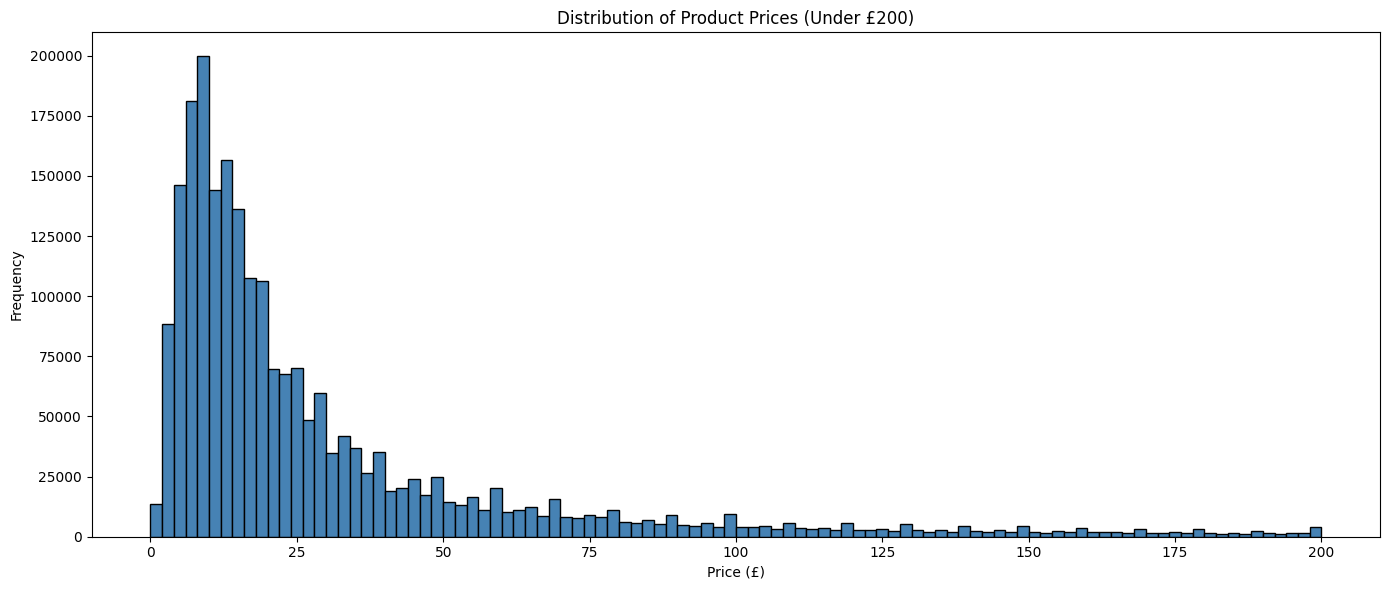

In [13]:
# Actually filter rows, don't just zoom the axis
filtered = amazon_uk[amazon_uk['price'] <= 200]

plt.figure(figsize=(14, 6))
filtered['price'].plot(kind='hist', bins=100, color='steelblue', edgecolor='black')
plt.title('Distribution of Product Prices (Under £200)')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

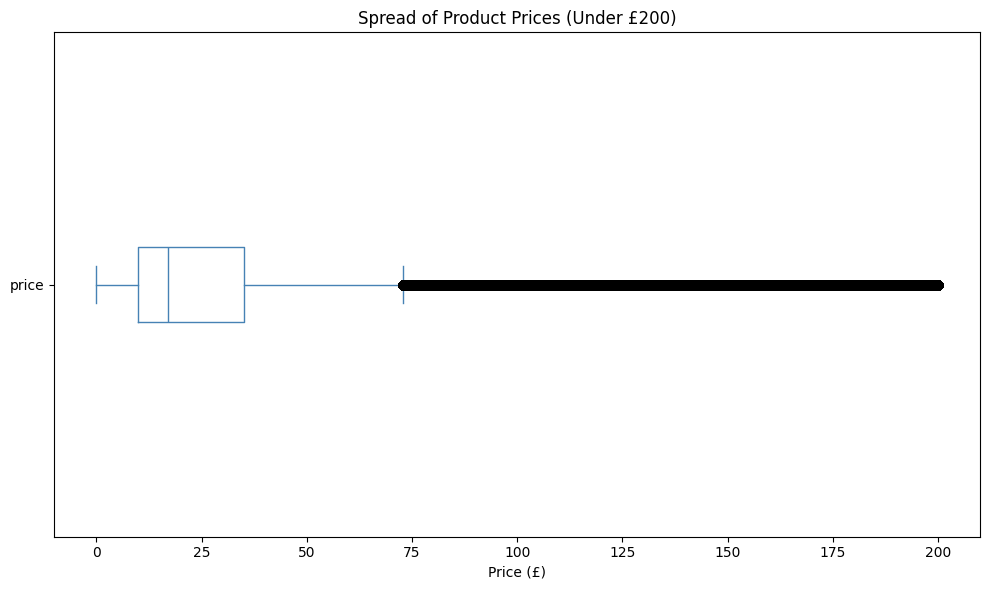

In [14]:
#Box Plot — spotting outliers

filtered = amazon_uk[amazon_uk['price'] <= 200]

plt.figure(figsize=(10, 6))
filtered['price'].plot(kind='box', vert=False, color='steelblue')
plt.title('Spread of Product Prices (Under £200)')
plt.xlabel('Price (£)')
plt.tight_layout()
plt.show()

#3.1.

In [15]:
mean_stars   = amazon_uk['stars'].mean()
median_stars = amazon_uk['stars'].median()
mode_stars   = amazon_uk['stars'].mode()[0]

print(f"Mean stars:   {mean_stars:.2f}")
print(f"Median stars: {median_stars:.2f}")
print(f"Mode stars:   {mode_stars:.2f}")

Mean stars:   2.15
Median stars: 0.00
Mode stars:   0.00


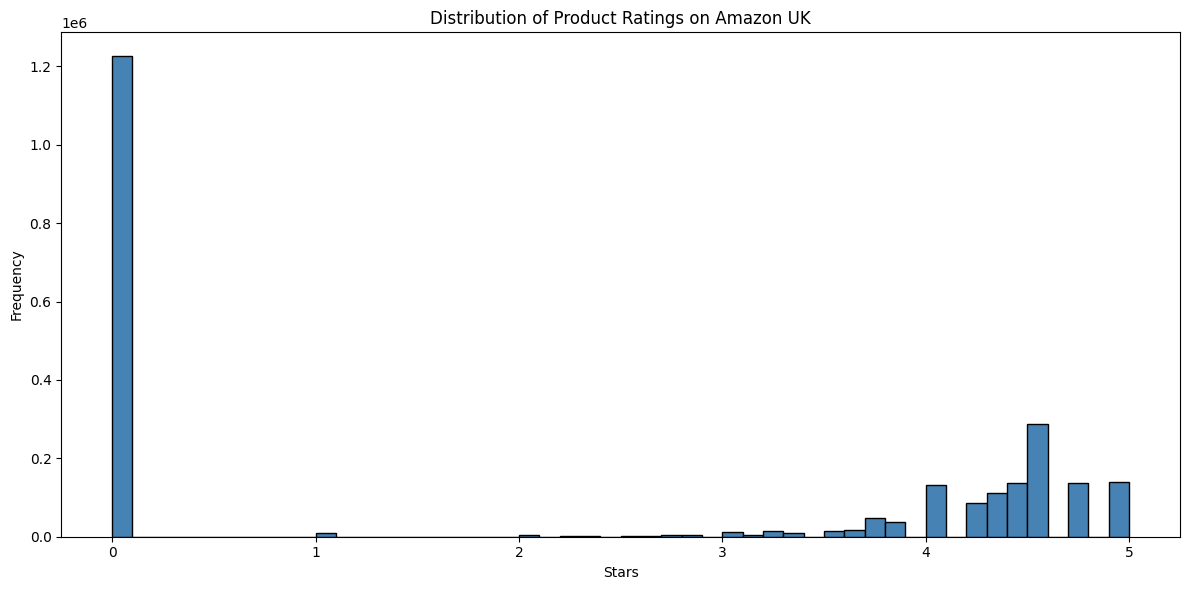

In [16]:
plt.figure(figsize=(12, 6))
amazon_uk['stars'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Product Ratings on Amazon UK')
plt.xlabel('Stars')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [23]:
no_ratings = (amazon_uk['stars'] == 0).sum()
total = len(amazon_uk)

print(f"Products with 0 stars: {no_ratings:,}")
print(f"As a percentage: {no_ratings/total*100:.2f}%")

Products with 0 stars: 1,225,641
As a percentage: 50.16%


After observation concluded there are far TOO MANY 0's - which means people did not rate at all. It means absence, not clear rating. I will replace it with NaN it and only consider the true inputs (assuming the positivity bias in ratings).

In [26]:
# Convert to numeric, any non-numeric values (like NA) become NaN automatically
amazon_uk['stars'] = pd.to_numeric(amazon_uk['stars'], errors='coerce')

# Verify it worked
print(amazon_uk['stars'].dtype)
print(amazon_uk['stars'].unique()[:20])

float64
[4.7 4.6 4.5 4.8 nan 4.4 4.3 4.1 4.9 5.  3.8 3.6 4.  4.2 3.  3.9 2.5 3.4
 3.7 3.2]


In [27]:
mean_stars   = amazon_uk['stars'].mean()
median_stars = amazon_uk['stars'].median()
mode_stars   = amazon_uk['stars'].mode()[0]

print(f"Mean stars:   {mean_stars:.2f}")
print(f"Median stars: {median_stars:.2f}")
print(f"Mode stars:   {mode_stars:.2f}")

Mean stars:   4.32
Median stars: 4.40
Mode stars:   4.50


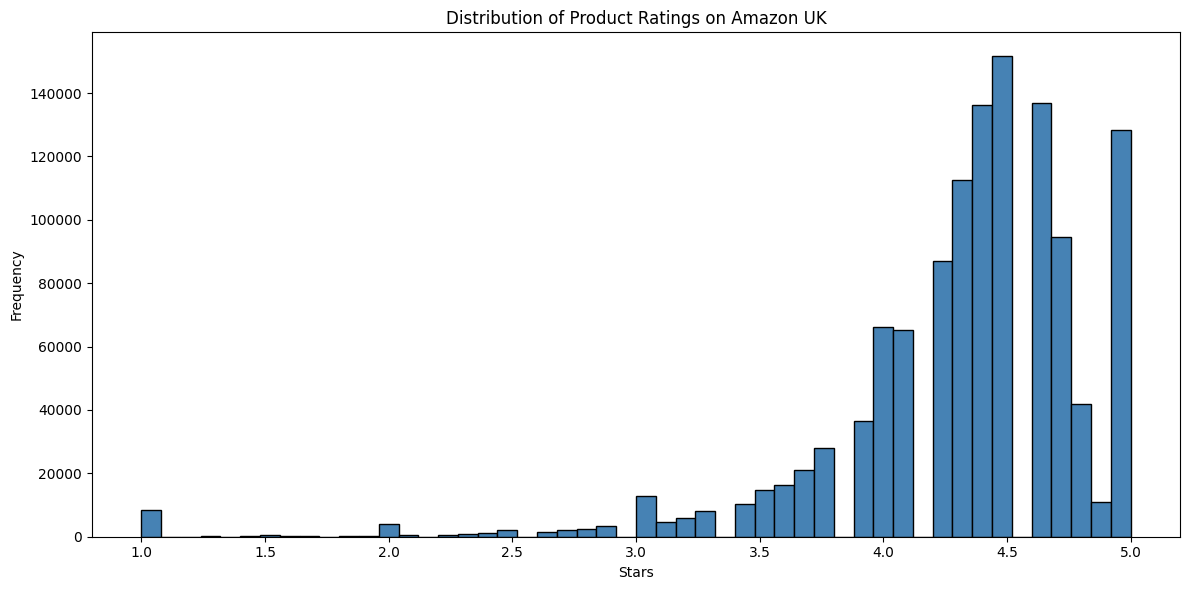

In [28]:
plt.figure(figsize=(12, 6))
amazon_uk['stars'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Product Ratings on Amazon UK')
plt.xlabel('Stars')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This confirms the "positive bias" trend in ratings, where the ratings are concentrated between 4 and 5.

#3.2.

In [29]:
variance = amazon_uk['stars'].var()
std_dev  = amazon_uk['stars'].std()
q1       = amazon_uk['stars'].quantile(0.25)
q3       = amazon_uk['stars'].quantile(0.75)
iqr      = q3 - q1

print(f"Variance:  {variance:.4f}")
print(f"Std Dev:   {std_dev:.4f}")
print(f"Q1:        {q1:.2f} stars")
print(f"Q3:        {q3:.2f} stars")
print(f"IQR:       {iqr:.2f} stars")

Variance:  0.3083
Std Dev:   0.5553
Q1:        4.10 stars
Q3:        4.60 stars
IQR:       0.50 stars


They are remarkably consistent. The middle 50% of all products on Amazon UK are rated within just a 0.50 star window (4.10 – 4.60). That's an incredibly tight band on a 5 point scale.

#3.3.

In [30]:
skewness = amazon_uk['stars'].skew()
kurtosis = amazon_uk['stars'].kurt()

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

Skewness: -2.3796
Kurtosis: 9.7819


Ratings are not normally distributed at all — they are highly left skewed with an extremely sharp peak around 4.0–4.5. This is classic Amazon positivity bias — customers tend to only buy products they already expect to like.

#3.4.

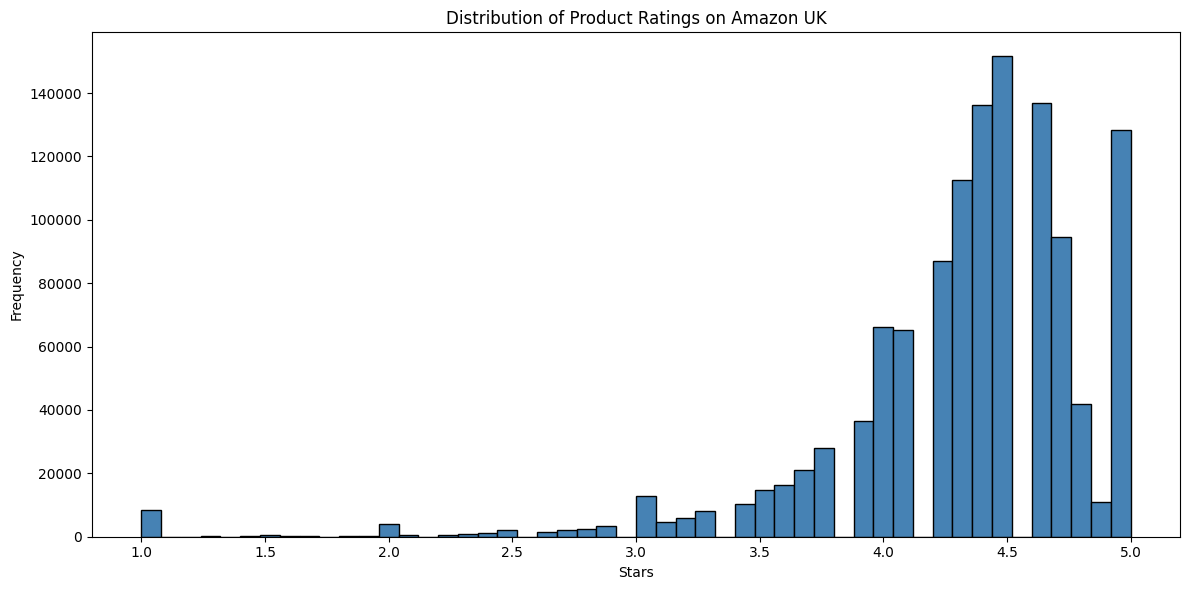

In [31]:
plt.figure(figsize=(12, 6))
amazon_uk['stars'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Product Ratings on Amazon UK')
plt.xlabel('Stars')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This does not confirm a normal distribution at all. This is negatively skewed and extremely high kurtosis.

Business-centric report:

The Amazon UK dataset, that has about 2.4 million product listings across multiple categories, reveals a marketplace dominated by high-volume, low-cost products with a small but influential tail of premium items. The most listed categories reflect everyday consumer demand, with listing frequency heavily concentrated among a handful of top categories. On pricing, the typical product costs around £19.09 (median), yet the mean price of £89.24 tells a different story — a relatively small number of high-ticket items inflate the average significantly, a pattern confirmed by an extremely wide price range and a standard deviation far exceeding the median. The most common price point of £9.99 underscores how pervasive psychological pricing is among sellers, with the majority of listings targeting budget-conscious shoppers. Customer ratings paint a consistently positive picture — the average product is rated between 4.1 and 4.6 stars, with a mode of 4.5 and an IQR of just 0.50, indicating remarkably little disagreement among customers. This positivity is not accidental; with a skewness of -2.38 and kurtosis of 9.78, ratings are sharply peaked at the high end, reflecting both buyer self-selection and natural marketplace filtering that removes poorly rated listings over time. In summary, Amazon UK operates as a high-volume, budget-led marketplace where sellers cluster around low price points and customers overwhelmingly report positive experiences.